Analyze the proteome for the E. coli core model
- Map measured protein abundaces to model genes/enzymes

In [2]:
import pandas as pd
import cobra
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assign subcellular location to each gene

### Assign uniprotid to each gene in the extracted proteome set

                            Glucose        LB  Glycerol + AA   Acetate  \
Bnumber Uniprot Accession                                                
b3988   P0A8T7             0.715349  1.844515       1.159331  0.561253   
b3987   P0A8V2             0.989135  2.221614       1.299346  0.665163   
b0118   P36683             1.178283  2.575086       2.722244  3.543745   
b2557   P15254             0.576304  0.192554       0.548796  0.337313   
b3212   P09831             0.774653  0.163742       0.176652  0.369212   
...                             ...       ...            ...       ...   
NaN     P36667             0.000167  0.001322            NaN  0.000097   
        P0AC78             0.000084  0.000012       0.000002  0.000249   
        P76164             0.002472  0.000022       0.000066  0.000770   
        P38506             0.000119  0.000300       0.000166  0.000093   
        Q46810             0.001575  0.000632            NaN  0.000451   

                           Fumarate  

/home/claud/anaconda3/envs/DFBA_PAM/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<Axes: >

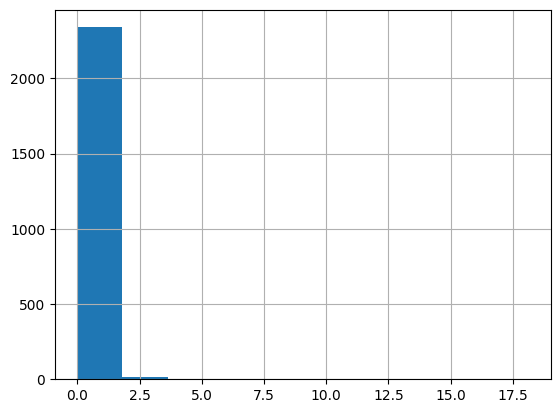

In [3]:
proteome_df_extract = pd.read_excel('../Data/proteome_data_extract_schmidt2016.xlsx',
                            sheet_name='ProteinMasses',
                            engine='openpyxl')

proteome_df_full = pd.read_excel('../Data/proteome_data_full_schmidt2016.xlsx',
                            sheet_name='Table S6',
                            engine='openpyxl',
                            header=2)

protein2location_df = pd.read_excel('../Data/proteome_data_extract_schmidt2016.xlsx',
                            sheet_name='SubcellularLocation',
                            engine='openpyxl')

proteome_df_full = proteome_df_full[['Bnumber', 'Uniprot Accession', 'Glucose.1']]
proteome_df_full = proteome_df_full.rename(columns = {'Glucose.1': 'Glucose'})

proteome_df = pd.merge(left=proteome_df_extract,
                       right=proteome_df_full,
                       how='left',
                       on=['Bnumber', 'Glucose']) # in fg/cell
proteome_df = pd.merge(left=proteome_df,
                       right=protein2location_df,
                       how='left',
                       on="Uniprot Accession")

# Move this column to the front
col = 'Uniprot Accession'
proteome_df = proteome_df[[col] + [c for c in proteome_df.columns if c != col]]
proteome_df = proteome_df.set_index(["Bnumber", "Uniprot Accession"])
print(proteome_df)
print(proteome_df.shape)

proteome_df['Glucose'].hist()


### Comparing proteomics data from Schmidt vs. Shannara's data


In [4]:
schmidt_proteome_df = proteome_df
shannara_proteome_df = pd.read_excel('../Data/proteome_data_full_shannara2024.xlsx', sheet_name='merged_data_with_location')

count_inner_memprot_schmidt = schmidt_proteome_df[schmidt_proteome_df['Cellular protein location'] == 'Cell inner membrane'].shape[0]
count_inner_memprot_shannara = shannara_proteome_df[shannara_proteome_df['Cellular protein location'] == 'Cell inner membrane'].shape[0]
print(f'Schmidt inner membrane proteins count: {count_inner_memprot_schmidt}')
print(f'Shannara inner membrane proteins count: {count_inner_memprot_shannara}')

Schmidt inner membrane proteins count: 319
Shannara inner membrane proteins count: 544


# Load proteome data
## Protein abundances

In [5]:
proteome_df = proteome_df
print(proteome_df.sum())


Glucose                    243.213004
LB                         367.033282
Glycerol + AA              326.575947
Acetate                    196.383788
Fumarate                   217.313417
Glucosamine                225.456560
Glycerol                   225.516494
Pyruvate                   213.887999
Chemostat µ=0.5            230.403545
Chemostat µ=0.35           205.415188
Chemostat µ=0.20           178.209255
Chemostat µ=0.12           162.811491
Stationary phase 1 day     139.699350
Stationary phase 3 days    138.953772
Osmotic-stress glucose     238.326344
42°C glucose               255.155370
pH6 glucose                250.635408
Xylose                     237.743430
Mannose                    224.978643
Galactose                  189.043807
Succinate                  220.553813
Fructose                   252.885190
dtype: float64


/tmp/ipykernel_66822/3508166927.py:2: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(proteome_df.sum())


## Growth rates

In [6]:
# load growth rate data [1/h] (Schmidt et al. 2016)
growth_rate_df = pd.read_excel('../Data/proteome_data_extract_schmidt2016.xlsx',
                                 sheet_name='GrowthRates',
                                 engine='openpyxl',
                                 index_col=0
                                 )
growth_rate_df['Cell volume [fL]'] = (
    -0.53 * growth_rate_df['Growth rates']**2
    + 2.41 * growth_rate_df['Growth rates']
    + 1.62
)


growth_rate_df['Cell dry weight [gDW]'] = growth_rate_df['Cell volume [fL]']/1e15 * 268.36 # 1e6 to convert uL to L and 268.36 gDW/L to convert L to gDW

print(growth_rate_df)

                         Growth rates  Cell volume [fL]  Cell dry weight [gDW]
Condition                                                                     
LB                               1.90          4.285700           1.150110e-12
Glycerol + AA                    1.27          3.825863           1.026709e-12
Acetate                          0.30          2.295300           6.159667e-13
Fumarate                         0.42          2.538708           6.812877e-13
Galactose                        0.26          2.210772           5.932828e-13
Glucose                          0.58          2.839508           7.620104e-13
Glucosamine                      0.46          2.616452           7.021511e-13
Glycerol                         0.47          2.635623           7.072958e-13
Pyruvate                         0.40          2.499200           6.706853e-13
Succinate                        0.44          2.577792           6.917763e-13
Fructose                         0.65          2.962

## Protein abundance in g/gDW

In [7]:
conditions = growth_rate_df.index.to_list()

for condition in conditions:
    proteome_df[condition] = proteome_df[condition]/1e15 / growth_rate_df.loc[condition]['Cell dry weight [gDW]']
proteome_df.to_excel('../Results/proteome_schmidt.xlsx')
print(proteome_df.sum())

Glucose                    0.319173
LB                         0.319129
Glycerol + AA              0.318080
Acetate                    0.318822
Fumarate                   0.318975
Glucosamine                0.321094
Glycerol                   0.318843
Pyruvate                   0.318910
Chemostat µ=0.5            0.318871
Chemostat µ=0.35           0.319125
Chemostat µ=0.20           0.319141
Chemostat µ=0.12           0.319048
Stationary phase 1 day     0.326201
Stationary phase 3 days    0.324460
Osmotic-stress glucose     0.318861
42°C glucose               0.319087
pH6 glucose                0.318979
Xylose                     0.318081
Mannose                    0.318083
Galactose                  0.318640
Succinate                  0.318822
Fructose                   0.318080
dtype: float64


/tmp/ipykernel_66822/1329641815.py:6: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(proteome_df.sum())


## COG

In [8]:
# load conversion table from gene to COG
gene2cog_df = pd.read_excel('../Data/proteome_data_extract_schmidt2016.xlsx',
                          sheet_name='Gene2COG',
                          engine='openpyxl',
                          index_col=0)
gene2cog_df

,COG ID,COG Name
Bnumber,,
b3988,K,Transcription
b3987,K,Transcription
b0118,C,Energy production and conversion
b2557,F,Nucleotide transport and metabolism
b3212,E,Amino acid transport and metabolism
...,...,...
NaN,-,NaN
NaN,-,NaN
NaN,-,NaN


# General proteome analysis
## RNA polymerase

<Axes: xlabel='Growth rates', ylabel='Proteinfraction'>

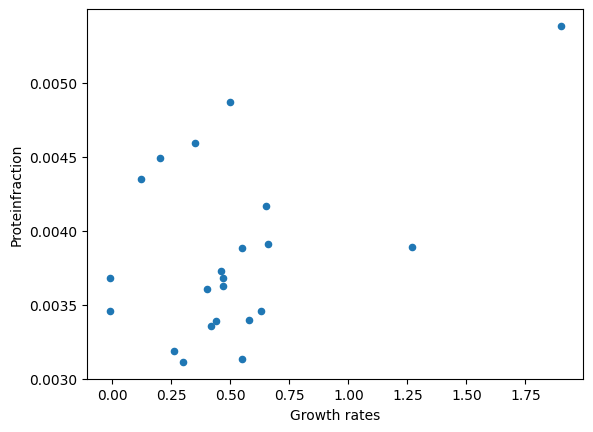

In [9]:
# analyze RNA polymerase abundances
# rnap_genes = ['b3988', 'b3987', 'b3295', 'b3067', 'b2741', 'b3202', 'b3649', 'b2573']
rnap_genes = ['b3295', 'b3987', 'b3988'], # rpoA, rpoB, rpoC -> RNA polymerase core enzyme 
# get abundaces of RNA polymerase genes (rnap_genes)
rnap_fractions_ds = proteome_df.loc[rnap_genes].sum(axis=0)
rnap_fractions_ds.rename('Proteinfraction', inplace=True)

# merge sum of protein abundaces with growth rate data
rnap_abundances_df = pd.concat([rnap_fractions_ds, growth_rate_df], axis=1)
rnap_abundances_df

# print as scatter plot
rnap_abundances_df.plot.scatter(x='Growth rates', y='Proteinfraction')

# Analyze proteome of E. coli core model


## Load model

In [10]:
model = cobra.io.read_sbml_model('../Models/iML1515.xml')

## Protein abundance of model proteins

In [11]:
genes_in_dataset = []

for g in model.genes:
    if g.id in proteome_df.index:
        genes_in_dataset.append(g.id)
    # else:
    #     print(f'{g.id} {g.name} not in proteome data')

# extract protein abundances for genes in dataset
proteome_model_df = proteome_df.loc[genes_in_dataset]
proteome_model_df = proteome_model_df[proteome_model_df['Cellular protein location'] != 'Cell inner membrane'] # exclude inner membrane proteins
print(proteome_model_df.sum())


Glucose                    0.164420
LB                         0.114599
Glycerol + AA              0.142661
Acetate                    0.198884
Fumarate                   0.180180
Glucosamine                0.177414
Glycerol                   0.173235
Pyruvate                   0.178179
Chemostat µ=0.5            0.178536
Chemostat µ=0.35           0.189523
Chemostat µ=0.20           0.193612
Chemostat µ=0.12           0.196403
Stationary phase 1 day     0.156769
Stationary phase 3 days    0.157688
Osmotic-stress glucose     0.168939
42°C glucose               0.156616
pH6 glucose                0.167341
Xylose                     0.167607
Mannose                    0.179371
Galactose                  0.193670
Succinate                  0.176895
Fructose                   0.167930
dtype: float64


/tmp/ipykernel_66822/1898806937.py:12: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(proteome_model_df.sum())


                         Protein abundance sum  Growth rates  \
Glucose                               0.164420          0.58   
LB                                    0.114599          1.90   
Glycerol + AA                         0.142661          1.27   
Acetate                               0.198884          0.30   
Fumarate                              0.180180          0.42   
Glucosamine                           0.177414          0.46   
Glycerol                              0.173235          0.47   
Pyruvate                              0.178179          0.40   
Chemostat µ=0.5                       0.178536          0.50   
Chemostat µ=0.35                      0.189523          0.35   
Chemostat µ=0.20                      0.193612          0.20   
Chemostat µ=0.12                      0.196403          0.12   
Stationary phase 1 day                0.156769         -0.01   
Stationary phase 3 days               0.157688         -0.01   
Osmotic-stress glucose                0.

/tmp/ipykernel_66822/684763254.py:2: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  proteome_model_sum_ds = proteome_model_df.sum(axis=0)


Text(0, 0.5, 'Model protein abundance')

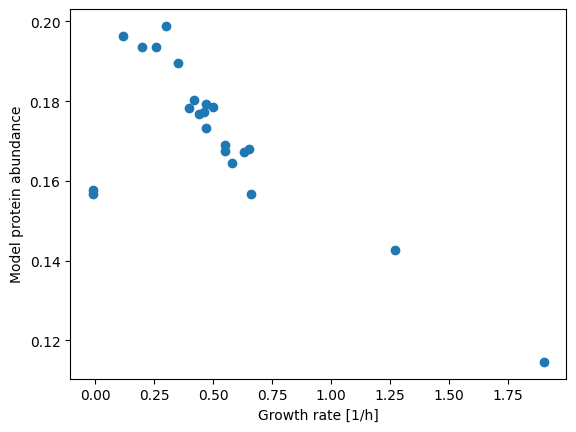

In [12]:
# sum protein abundances for each condition
proteome_model_sum_ds = proteome_model_df.sum(axis=0)
proteome_model_sum_ds.rename('Protein abundance sum', inplace=True)

# merge sum of protein abundaces with growth rate data
proteome_model_sum_df = pd.concat([proteome_model_sum_ds, growth_rate_df], axis=1)
print(proteome_model_sum_df)

# plot sum of protein abundances against growth rate as scatter plot
fig, ax = plt.subplots()
ax.scatter(proteome_model_sum_df['Growth rates'], proteome_model_sum_df['Protein abundance sum'])
ax.set_xlabel('Growth rate [1/h]')
ax.set_ylabel('Model protein abundance')


# Translational sector (J)

/tmp/ipykernel_66822/1737234587.py:6: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  proteome_sum_j = proteome_df.loc[bnumbers_j].sum(axis=0)


Text(0, 0.5, 'Translational protein abundance')

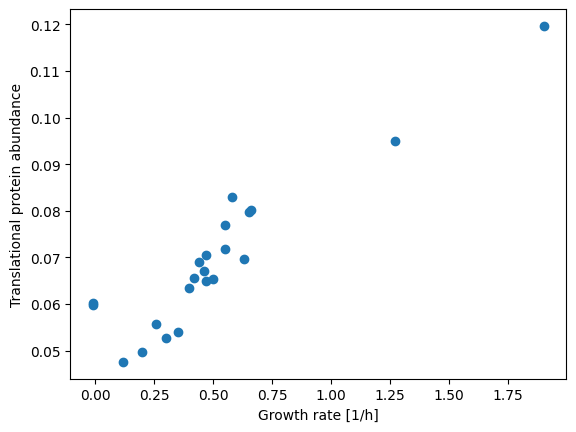

In [13]:
# sum protein abundances of proteins from COG J
# get Bnumbers associated with COG ID J from gene2cog_df
bnumbers_j = gene2cog_df.loc[gene2cog_df['COG ID'] == 'J'].index.to_list()

# sum protein abundances of translational protein sector
proteome_sum_j = proteome_df.loc[bnumbers_j].sum(axis=0)
proteome_sum_j.rename('Protein abundance sum', inplace=True)

# merge with growth rates
proteome_sum_j_df = pd.concat([proteome_sum_j, growth_rate_df], axis=1)

# plot sum of protein abundances against growth rate as scatter plot
fig, ax = plt.subplots()
ax.scatter(proteome_sum_j_df['Growth rates'], proteome_sum_j_df['Protein abundance sum'])
ax.set_xlabel('Growth rate [1/h]')
ax.set_ylabel('Translational protein abundance')

## Merge translational and model protein sector 

                         Protein abundance sum  Growth rates  \
Stationary phase 1 day                0.217095         -0.01   
Stationary phase 3 days               0.217401         -0.01   
Chemostat µ=0.12                      0.244008          0.12   
Chemostat µ=0.20                      0.243436          0.20   
Galactose                             0.249395          0.26   
Acetate                               0.251666          0.30   
Chemostat µ=0.35                      0.243567          0.35   
Pyruvate                              0.241621          0.40   
Fumarate                              0.245767          0.42   
Succinate                             0.245823          0.44   
Glucosamine                           0.244463          0.46   
Mannose                               0.244428          0.47   
Glycerol                              0.243870          0.47   
Chemostat µ=0.5                       0.243875          0.50   
Osmotic-stress glucose                0.

Text(0, 0.5, 'Protein abundance')

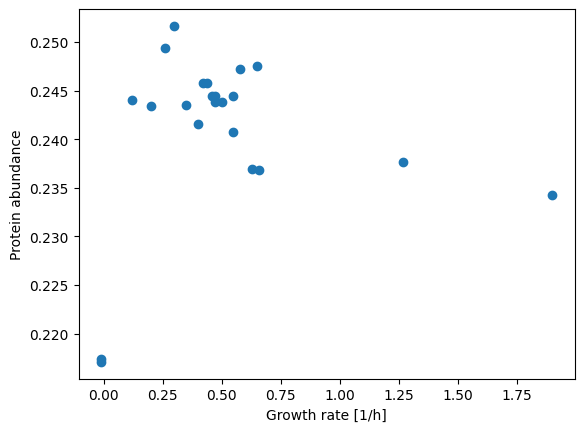

In [14]:
# Merge protein abundances
proteome_sum_merge = proteome_model_sum_df.copy()
proteome_sum_merge['Protein abundance sum'] = proteome_sum_merge['Protein abundance sum'] + proteome_sum_j_df['Protein abundance sum']
proteome_sum_merge_sort = proteome_sum_merge.sort_values(by='Growth rates')
print(proteome_sum_merge_sort)

# plot sum of protein abundances against growth rate as scatter plot
fig, ax = plt.subplots()
ax.scatter(proteome_sum_merge['Growth rates'], proteome_sum_merge['Protein abundance sum'])
ax.set_xlabel('Growth rate [1/h]')
ax.set_ylabel('Protein abundance')

In [15]:
# mean protein abundances for each condition
protein_abundance_mean = proteome_sum_merge['Protein abundance sum'].mean()
print(f'Mean total protein abundance: {round(protein_abundance_mean, 4)} g/gDW')

Mean total protein abundance: 0.241 g/gDW


## Unused Protein Sector

In [16]:
#linear relation growth rate and protein abundance
protein_vs_mu = linregress(x=proteome_sum_merge['Growth rates'], y = proteome_sum_merge['Protein abundance sum'])

Text(0, 0.5, 'Protein abundance')

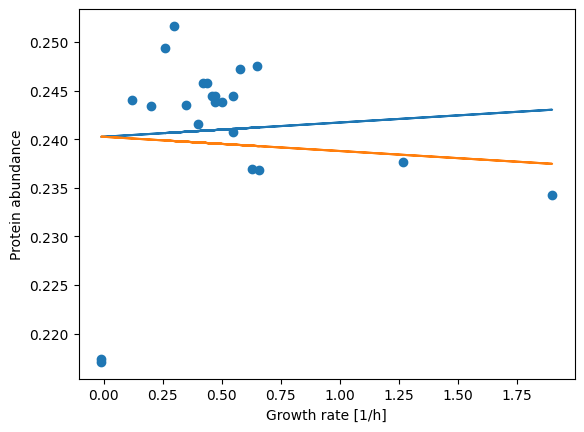

In [17]:
slope = protein_vs_mu.slope
intercept = protein_vs_mu.intercept

y= [intercept + slope*mu for mu in proteome_sum_merge['Growth rates']]
#inverse relation is the fraction of unused proteins to fill up the protein space
y2 = [intercept - slope*mu for mu in proteome_sum_merge['Growth rates']]

# plot sum of protein abundances against growth rate as scatter plot
fig, ax = plt.subplots()
ax.plot(proteome_sum_merge['Growth rates'],y)
ax.plot(proteome_sum_merge['Growth rates'],y2)
ax.scatter(proteome_sum_merge['Growth rates'], proteome_sum_merge['Protein abundance sum'])
ax.set_xlabel('Growth rate [1/h]')
ax.set_ylabel('Protein abundance')

In [18]:
print(f'Max total protein abundance: {round(proteome_sum_merge["Protein abundance sum"].mean(), 5)} g/gDW')
print('Unused enzymes at zero growth: ', round(proteome_sum_merge['Protein abundance sum']['LB']-intercept,4), ' g/gDW')
print('Change in unused enzymes with increasing growth rate: ', -round(slope,4), ' g/gDW/h')

Max total protein abundance: 0.241 g/gDW
Unused enzymes at zero growth:  -0.006  g/gDW
Change in unused enzymes with increasing growth rate:  -0.0015  g/gDW/h
